# Load libraries

In [10]:
suppressMessages(library("data.table"))
suppressMessages(library("withr"))
suppressMessages(library("ggplot2"))
suppressMessages(library("farver"))
suppressMessages(library("labeling"))
suppressMessages(library("optparse"))
suppressMessages(library("dplyr"))
suppressMessages(library("withr"))
suppressMessages(library("backports"))
suppressMessages(library("broom"))
suppressMessages(library("rstudioapi"))
suppressMessages(library("tzdb"))
suppressMessages(library("svglite"))
suppressMessages(library("ggeasy"))
suppressMessages(library("tidyverse"))
suppressMessages(library("BiocGenerics"))
suppressMessages(library("S4Vectors"))
suppressMessages(library("IRanges"))
suppressMessages(library("GenomeInfoDb"))
suppressMessages(library("GenomicRanges"))
suppressMessages(library("Biobase"))
suppressMessages(library("AnnotationDbi"))
suppressMessages(library("GO.db"))
suppressMessages(library("org.Hs.eg.db"))
suppressMessages(library("ggrepel"))
suppressMessages(library("RColorBrewer"))
suppressMessages(library("svglite"))
suppressMessages(library("cowplot"))
suppressMessages(library("Matrix"))
suppressMessages(library("rtracklayer"))
suppressMessages(library("Biostrings"))
suppressMessages(library("ggrepel"))
suppressMessages(library("ggnewscale"))
suppressMessages(library("splitstackshape"))
suppressMessages(library("viridis"))
suppressMessages(library("viridis"))
suppressMessages(library("ggsci"))
suppressMessages(library("plyr"))
suppressMessages(library("ggupset"))
suppressMessages(library("patchwork"))
suppressMessages(library("ggh4x"))
suppressMessages(library("ComplexHeatmap"))
suppressMessages(library("tidyr"))
suppressMessages(library("circlize"))
suppressMessages(library("grid"))
suppressMessages(library("ggrepel"))
suppressMessages(library("cluster"))
suppressMessages(library("clusterProfiler"))
suppressMessages(library("projectStyleR"))
library(lme4)
library(parallel)
library(UpSetR)

## Load palettes

In [11]:
palettes_path <- system.file("palettes.yaml", package = "projectStyleR")
themes_path <- system.file("themes.yaml", package = "projectStyleR")

In [12]:
palettes <- yaml::read_yaml(palettes_path)
themes <- yaml::read_yaml(themes_path)

In [13]:
available_palettes()
available_themes()

Available palettes:

 - primary

 - vibrant

 - muted_tones

Available themes:

 - default

 - publication



# Read in plotting files

In [19]:
cat("=== coverage_dir (edge level, Representation_ERs_v5.ipynb) ===\n")
print(list.files("/nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis",
                  recursive = TRUE, full.names = TRUE))

#cat("\n=== Patterns_in_factors_refined (full tree, pattern level) ===\n")
#print(list.files("/nfs/team151/mt19/overhaul_classification_factors_with_programs/Patterns_in_factors_refined",
#                  recursive = TRUE, full.names = TRUE))

#cat("\n=== cis_eQTL_level_exosome (cis-eQTL level, already confirmed) ===\n")
#print(list.files("/nfs/team151/mt19/overhaul_classification_factors_with_programs/cis_eQTL_level_exosome",
#                  recursive = TRUE, full.names = TRUE))

#cat("\n=== Searching for Factor_ER_v2.ipynb's outdir (program/factor level - path unknown) ===\n")
#print(system("find /nfs/team151/mt19 -iname '*factor_ER_within_vs_across*' 2>/dev/null", intern = TRUE))

=== coverage_dir (edge level, Representation_ERs_v5.ipynb) ===
 [1] "/nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis/edge_label_resource_dt.rds"           
 [2] "/nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis/edge_level_coverage.pdf"              
 [3] "/nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis/edge_level_coverage.png"              
 [4] "/nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis/edge_level_coverage.svg"              
 [5] "/nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis/forest_plot_collapsed_fisher.pdf"     
 [6] "/nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis/forest_plot_collapsed_fisher.png"     
 [7] "/nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis/forest_plot_collapsed_fisher.svg"     
 [8] "/nfs/team151/mt19/overhaul_classification_

# PATH

In [27]:
global_plots_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/Global_plots/"
dir.create(global_plots_dir, recursive = TRUE, showWarnings = FALSE)
cat("Created:", global_plots_dir, "\n")

Created: /nfs/team151/mt19/overhaul_classification_factors_with_programs/Global_plots/ 


# Cell — load the cis-eQTL bundle's metadata (colors/mappings)

In [28]:
cis_eqtl_bundle_path <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/cis_eQTL_level_exosome/cis_eqtl_exosome_results_bundle.rds"
results_bundle <- readRDS(cis_eqtl_bundle_path)

plot_metadata    <- results_bundle$plot_metadata
resource_colors  <- plot_metadata$resource_colors   # named vector: CollecTRI, SCENIC_activator, SCENIC_repressor, RBP, LR, PPI, MEROPS, Exosome

cat("Loaded resource_colors from cis-eQTL bundle:\n")
print(resource_colors)

Loaded resource_colors from cis-eQTL bundle:
       CollecTRI SCENIC_activator SCENIC_repressor              RBP 
       "#D55E00"         "orange"          "black"        "#CC79A7" 
              LR              PPI           MEROPS          Exosome 
       "#009E73"        "#0072B2"         "grey50"         "purple" 


# Cell — locate and load the raw edge-level result files:

In [21]:
cat("All result files:\n")
print(basename(result_files))

## Parse resource_key, direction, eqtl_condition directly from filenames
## (format: <resource_key>_<direction>_<eqtl_condition>_result.tsv) and look
## for duplicates - i.e. more than one file per unique combination.
parsed_names <- data.table(
  file = basename(result_files),
  stem = sub("_result\\.tsv$", "", basename(result_files))
)

known_conditions <- c("Across_full", "Across_GWAS_colocalized", "Within_full", "Within_GWAS_colocalized")
known_directions <- c("forward", "reverse", "undirected")

parsed_names[, eqtl_condition := known_conditions[sapply(stem, function(s) which(sapply(known_conditions, function(c) endsWith(s, c)))[1])]]
parsed_names[, remainder1 := mapply(function(s, c) sub(paste0("_", c, "$"), "", s), stem, eqtl_condition)]
parsed_names[, direction := known_directions[sapply(remainder1, function(s) which(sapply(known_directions, function(d) endsWith(s, d)))[1])]]
parsed_names[, resource_key := mapply(function(s, d) sub(paste0("_", d, "$"), "", s), remainder1, direction)]

cat("\nUnique (resource_key, direction, eqtl_condition) combinations:", 
    uniqueN(parsed_names[, .(resource_key, direction, eqtl_condition)]), "\n")
cat("Total files:", nrow(parsed_names), "\n")

cat("\n=== Combinations with MORE THAN ONE file (duplicates/reruns) ===\n")
dup_check <- parsed_names[, .N, by = .(resource_key, direction, eqtl_condition)][N > 1]
print(dup_check)

if (nrow(dup_check) > 0) {
  cat("\nAll files for the first duplicated combination, with mtime:\n")
  first_dup <- dup_check[1]
  dup_files <- parsed_names[resource_key == first_dup$resource_key & 
                             direction == first_dup$direction & 
                             eqtl_condition == first_dup$eqtl_condition]$file
  print(file.info(paste0(results_dir, dup_files))[, "mtime", drop = FALSE])
}

cat("\n=== resource_key values found (check against the 8 expected from 405_enrichment_array_v3.sh) ===\n")
print(table(parsed_names$resource_key))

All result files:
 [1] "CollecTRI_strict_forward_Across_GWAS_colocalized_result.tsv"                                 
 [2] "CollecTRI_strict_forward_Across_full_result.tsv"                                             
 [3] "CollecTRI_strict_forward_Within_GWAS_colocalized_result.tsv"                                 
 [4] "CollecTRI_strict_forward_Within_full_result.tsv"                                             
 [5] "CollecTRI_strict_reverse_Across_GWAS_colocalized_result.tsv"                                 
 [6] "CollecTRI_strict_reverse_Across_full_result.tsv"                                             
 [7] "CollecTRI_strict_reverse_Within_GWAS_colocalized_result.tsv"                                 
 [8] "CollecTRI_strict_reverse_Within_full_result.tsv"                                             
 [9] "Liana_lenient_forward_Across_GWAS_colocalized_result.tsv"                                    
[10] "Liana_lenient_forward_Across_full_result.tsv"                               

In [22]:
## =============================================================================
## Edge level: reconstruct combined_results from the 48+8 raw per-job files.
## EXCLUDES "SCENIC_regulon_same_dataset_single_tier" (8 files) - this is the
## pre-split combined SCENIC resource, superseded by the activator/repressor
## split (see Overhaul_finding_patterns_v11.ipynb changelog, Methods.md
## section 6). Its own array script (405_enrichment_array_v3.sh) explicitly
## does not define this resource_key and warns against silently folding in
## anything outside its declared 8-resource list. Retaining only the 56
## combinations matching Methods.md's stated design ("12 directed + 2
## undirected x 4 conditions = 56 tests total").
## =============================================================================
results_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/results_v2/"
result_files_all <- list.files(results_dir, pattern = "_result\\.tsv$", full.names = TRUE)
cat(length(result_files_all), "result files found on disk\n")

excluded_pattern <- "SCENIC_regulon_same_dataset_single_tier_"
n_excluded <- sum(grepl(excluded_pattern, basename(result_files_all), fixed = TRUE))
cat("Excluding", n_excluded, "files matching pre-split combined SCENIC resource:", excluded_pattern, "\n")

result_files <- result_files_all[!grepl(excluded_pattern, basename(result_files_all), fixed = TRUE)]
cat("Remaining result files:", length(result_files), "(expect 56, per Methods.md)\n")
stopifnot(length(result_files) == 56)

edge_level_raw <- rbindlist(lapply(result_files, function(f) {
  dt <- fread(f)
  dt[, source_file := basename(f)]
  dt
}), fill = TRUE)

cat("Rows loaded:", nrow(edge_level_raw), "\n")
print(names(edge_level_raw))

64 result files found on disk
Excluding 8 files matching pre-split combined SCENIC resource: SCENIC_regulon_same_dataset_single_tier_ 
Remaining result files: 56 (expect 56, per Methods.md)
Rows loaded: 56 
 [1] "analysis"      "direction"     "condition"     "observed_hits"
 [5] "null_mean"     "null_sd"       "z_score"       "p_enrichment" 
 [9] "is_untestable" "source_file"  


In [23]:
edge_level_raw[, stringency_detail := trimws(sub("\\|.*$", "", condition))]
edge_level_raw[, eqtl_condition    := trimws(sub("^.*eQTL:\\s*", "", condition))]

known_conditions <- c("Across_GWAS_colocalized", "Within_GWAS_colocalized", "Across_full", "Within_full")
cat("eqtl_condition values found:\n")
print(table(edge_level_raw$eqtl_condition))
stopifnot(all(edge_level_raw$eqtl_condition %in% known_conditions))

n_mismatch <- sum(!mapply(function(f, cond) endsWith(sub("_result\\.tsv$", "", f), cond),
                           edge_level_raw$source_file, edge_level_raw$eqtl_condition))
cat("Filename/condition-string mismatches:", n_mismatch, "(expect 0)\n")
stopifnot(n_mismatch == 0)

edge_level_raw[, resource_name := analysis]
cat("\nresource_name values found:\n")
print(table(edge_level_raw$resource_name))
cat("\ndirection values found:\n")
print(table(edge_level_raw$direction))

eqtl_condition values found:

Across_GWAS_colocalized             Across_full Within_GWAS_colocalized 
                     14                      14                      14 
            Within_full 
                     14 
Filename/condition-string mismatches: 0 (expect 0)

resource_name values found:

                            CollecTRI                                 Liana 
                                    8                                     8 
                               MEROPS                               POSTAR3 
                                    8                                     8 
SCENIC_regulon_activator_same_dataset SCENIC_regulon_repressor_same_dataset 
                                    8                                     8 
                  STRING_experimental 
                                    8 

direction values found:

   forward    reverse undirected 
        24         24          8 


In [24]:
edge_level_raw[, edge_type := sub("_.*", "", eqtl_condition)]
edge_level_raw[, edge_type := factor(edge_type, levels = c("Within", "Across"))]

edge_level_raw[, graph_type := ifelse(grepl("GWAS_colocalized", eqtl_condition), "GWAS_colocalized", "full")]
edge_level_raw[, graph_type := factor(graph_type, levels = c("full", "GWAS_colocalized"))]

edge_level_raw[, neg_log10_p := -log10(p_enrichment)]
edge_level_raw[, fold_enrichment := observed_hits / null_mean]

## resource_display keyed on the ACTUAL resource_name values (7, no
## stringency suffix) - STRING_experimental covers both PPI bands under one
## resource_name, distinguished instead by stringency_detail (parsed from
## 'condition' two cells back), not by resource_name itself.
resource_display_labels <- c(
  "STRING_experimental"                    = "PPI (STRING, experimental)",
  "CollecTRI"                               = "TF-target (CollecTRI)",
  "Liana"                                   = "Ligand-Receptor (Liana)",
  "POSTAR3"                                 = "RBP-target (POSTAR3)",
  "MEROPS"                                  = "Peptidase-substrate (MEROPS)",
  "SCENIC_regulon_activator_same_dataset"   = "activator TF-target (SCENIC)",
  "SCENIC_regulon_repressor_same_dataset"   = "repressor TF-target (SCENIC)"
)
cat("resource_name values NOT covered by resource_display_labels (should be empty):\n")
print(setdiff(unique(edge_level_raw$resource_name), names(resource_display_labels)))
stopifnot(all(edge_level_raw$resource_name %in% names(resource_display_labels)))
edge_level_raw[, resource_display := resource_display_labels[resource_name]]

## Distinguish STRING strict vs lenient band via stringency_detail specifically
cat("\nstringency_detail values for STRING_experimental rows:\n")
print(unique(edge_level_raw[resource_name == "STRING_experimental"]$stringency_detail))

direction_display_labels <- c(
  "forward"    = "cis-eQTL \u2192 trans-eQTL",
  "reverse"    = "trans-eQTL \u2192 cis-eQTL",
  "undirected" = "Undirected (PPI)"
)
edge_level_raw[, direction_display := direction_display_labels[direction]]

resource_name values NOT covered by resource_display_labels (should be empty):
character(0)

stringency_detail values for STRING_experimental rows:
[1] "score_experimentally_determined_interaction >= 0.1 MINUS score_experimentally_determined_interaction >= 0.4"
[2] "score_experimentally_determined_interaction >= 0.4"                                                         


In [25]:
## Map the two literal stringency_detail strings for STRING to strict/lenient,
## matching the "strict"/"lenient" convention used throughout Factor_ER_v2.ipynb
## and Overhaul_finding_patterns_v11.ipynb. All non-STRING resources get a
## single stringency tier by design (see Methods.md), labeled directly.
edge_level_raw[, stringency_label := fcase(
  resource_name == "STRING_experimental" & stringency_detail == "score_experimentally_determined_interaction >= 0.4", "strict",
  resource_name == "STRING_experimental" & grepl("MINUS", stringency_detail, fixed = TRUE), "lenient_band_0.1_to_0.4",
  default = "single_tier"
)]
cat("stringency_label distribution:\n")
print(table(edge_level_raw$resource_name, edge_level_raw$stringency_label))

n_testable <- sum(!edge_level_raw$is_untestable)

edge_level_raw[, p_adj_BH := NA_real_]
edge_level_raw[is_untestable == FALSE, p_adj_BH := p.adjust(p_enrichment, method = "BH")]

edge_level_raw[, p_adj_bonferroni := NA_real_]
edge_level_raw[is_untestable == FALSE, p_adj_bonferroni := pmin(p_enrichment * n_testable, 1)]

edge_level_raw[, sig_BH_05 := !is.na(p_adj_BH) & p_adj_BH < 0.05]

combined_results <- edge_level_raw
cat("\nTestable:", n_testable, "/", nrow(combined_results), "(expect close to 56, minus any zero-variance-null rows)\n")
print(combined_results[order(p_enrichment)][, .(resource_display, stringency_label, direction_display, eqtl_condition,
                                                  observed_hits, null_mean, fold_enrichment,
                                                  z_score, p_enrichment, p_adj_BH, sig_BH_05)])

stringency_label distribution:
                                       
                                        lenient_band_0.1_to_0.4 single_tier
  CollecTRI                                                   0           8
  Liana                                                       0           8
  MEROPS                                                      0           8
  POSTAR3                                                     0           8
  SCENIC_regulon_activator_same_dataset                       0           8
  SCENIC_regulon_repressor_same_dataset                       0           8
  STRING_experimental                                         4           0
                                       
                                        strict
  CollecTRI                                  0
  Liana                                      0
  MEROPS                                     0
  POSTAR3                                    0
  SCENIC_regulon_activator_same_dataset      0

In [26]:
## Exact Poisson CI on observed_hits (Garwood/exact method - standard,
## not derived here from scratch beyond the well-known qchisq relationship),
## converted to a CI on fold_enrichment by dividing by null_mean, matching
## the "fold_ci_low"/"fold_ci_high" columns referenced in Representation_ERs_v5.ipynb.
## NaN fold_enrichment rows (observed_hits==0 AND null_mean==0) get NA CIs,
## not an artificial 0/0 bound.
poisson_ci_fold <- function(observed, null_mean, conf_level = 0.95) {
  alpha <- 1 - conf_level
  lower_count <- ifelse(observed == 0, 0, qchisq(alpha / 2, 2 * observed) / 2)
  upper_count <- qchisq(1 - alpha / 2, 2 * (observed + 1)) / 2
  fold_lo <- ifelse(null_mean > 0, lower_count / null_mean, NA_real_)
  fold_hi <- ifelse(null_mean > 0, upper_count / null_mean, NA_real_)
  list(fold_ci_low = fold_lo, fold_ci_high = fold_hi)
}

ci_result <- poisson_ci_fold(combined_results$observed_hits, combined_results$null_mean)
combined_results[, fold_ci_low  := ci_result$fold_ci_low]
combined_results[, fold_ci_high := ci_result$fold_ci_high]

cat("Rows with NA CI (expect exactly the null_mean==0 rows):", sum(is.na(combined_results$fold_ci_low)), "\n")
print(combined_results[is.na(fold_ci_low), .(resource_display, eqtl_condition, observed_hits, null_mean, fold_enrichment)])

Rows with NA CI (expect exactly the null_mean==0 rows): 7 
               resource_display          eqtl_condition observed_hits null_mean
                         <char>                  <char>         <int>     <num>
1:      Ligand-Receptor (Liana) Across_GWAS_colocalized             0         0
2:      Ligand-Receptor (Liana) Across_GWAS_colocalized             0         0
3: Peptidase-substrate (MEROPS) Across_GWAS_colocalized             0         0
4: Peptidase-substrate (MEROPS) Within_GWAS_colocalized             0         0
5: Peptidase-substrate (MEROPS) Across_GWAS_colocalized             0         0
6: Peptidase-substrate (MEROPS) Within_GWAS_colocalized             0         0
7:         RBP-target (POSTAR3) Across_GWAS_colocalized             0         0
   fold_enrichment
             <num>
1:             NaN
2:             NaN
3:             NaN
4:             NaN
5:             NaN
6:             NaN
7:             NaN


In [29]:
stopifnot(exists("combined_results"))  # must already be built earlier in this session

edge_level_full <- combined_results[graph_type == "full"]
cat("Rows after restricting to graph_type == 'full':", nrow(edge_level_full), "/", nrow(combined_results), "\n")
print(table(edge_level_full$edge_type))

Rows after restricting to graph_type == 'full': 28 / 56 

Within Across 
    14     14 


In [30]:
## Maps combined_results$resource_name (7 distinct values, confirmed earlier)
## onto the same resource-key vocabulary as category_resource_map in the
## cis-eQTL notebook, so colors are directly comparable across levels.
edge_resource_key_map <- c(
  "CollecTRI"                              = "CollecTRI",
  "SCENIC_regulon_activator_same_dataset"  = "SCENIC_activator",
  "SCENIC_regulon_repressor_same_dataset"  = "SCENIC_repressor",
  "POSTAR3"                                 = "RBP",
  "Liana"                                   = "LR",
  "MEROPS"                                  = "MEROPS",
  "STRING_experimental"                     = "PPI"
)
stopifnot(all(edge_level_full$resource_name %in% names(edge_resource_key_map)))
edge_level_full[, resource_key := edge_resource_key_map[resource_name]]

## Row label: resource + stringency (for PPI strict/lenient) + direction
edge_level_full[, row_label := fifelse(
  stringency_label == "single_tier",
  paste(resource_display, direction_display, sep = " | "),
  paste(resource_display, stringency_label, direction_display, sep = " | ")
)]

## first test plot

In [33]:
## --- Legend display names (fill legend specifically) - MEROPS split onto
##     two lines per your request; others single-line ---
resource_legend_labels <- c(
  "CollecTRI"        = "CollecTRI",
  "SCENIC_activator"  = "SCENIC activator",
  "SCENIC_repressor"  = "SCENIC repressor",
  "RBP"               = "RBP (POSTAR3)",
  "LR"                = "Liana L-R",
  "MEROPS"            = "MEROPS\nPeptidase-substrate",
  "PPI"               = "PPI (STRING)"
)

## --- Row-label display names (y-axis, single line, no newline) ---
resource_row_display <- c(
  "CollecTRI"        = "CollecTRI",
  "SCENIC_activator"  = "SCENIC activator",
  "SCENIC_repressor"  = "SCENIC repressor",
  "RBP"               = "RBP (POSTAR3)",
  "LR"                = "Liana L-R",
  "MEROPS"            = "MEROPS Peptidase-substrate",
  "PPI"               = "PPI (STRING)"
)

## --- Per-resource role labels: forward = source-gene role, reverse =
##     target-gene role, per your specification (TF/RBP/Ligand/Peptidase
##     vs Target/Target/Receptor/Substrate). PPI is undirected so has no
##     role labels - distinguished by stringency (strict/lenient) instead. ---
role_labels <- list(
  CollecTRI        = c(forward = "TF",        reverse = "Target"),
  SCENIC_activator = c(forward = "TF",        reverse = "Target"),
  SCENIC_repressor = c(forward = "TF",        reverse = "Target"),
  RBP              = c(forward = "RBP",       reverse = "Target"),
  LR               = c(forward = "Ligand",    reverse = "Receptor"),
  MEROPS           = c(forward = "Peptidase", reverse = "Substrate")
)

edge_level_full[, role_label := mapply(function(rk, dir_val) {
  if (rk == "PPI") return(NA_character_)
  role_labels[[rk]][[dir_val]]
}, resource_key, direction)]

edge_level_full[, row_label := fifelse(
  resource_key == "PPI",
  paste(resource_row_display[resource_key], stringency_label, sep = " | "),
  paste(resource_row_display[resource_key], role_label, sep = " | ")
)]

## --- Explicit row order, top-to-bottom as specified: CollecTRI, SCENIC
##     activator, SCENIC repressor, RBP, Liana L-R, MEROPS, PPI strict,
##     PPI lenient - source/forward role before target/reverse role within
##     each directional resource, strict before lenient for PPI. ---
row_order_top_to_bottom <- c(
  "CollecTRI | TF", "CollecTRI | Target",
  "SCENIC activator | TF", "SCENIC activator | Target",
  "SCENIC repressor | TF", "SCENIC repressor | Target",
  "RBP (POSTAR3) | RBP", "RBP (POSTAR3) | Target",
  "Liana L-R | Ligand", "Liana L-R | Receptor",
  "MEROPS Peptidase-substrate | Peptidase", "MEROPS Peptidase-substrate | Substrate",
  "PPI (STRING) | strict", "PPI (STRING) | lenient_band_0.1_to_0.4"
)

cat("Rows in data not covered by the explicit order (should be empty):\n")
print(setdiff(unique(edge_level_full$row_label), row_order_top_to_bottom))
stopifnot(length(setdiff(unique(edge_level_full$row_label), row_order_top_to_bottom)) == 0)

Rows in data not covered by the explicit order (should be empty):
character(0)


In [43]:
## =============================================================================
## Updated y-axis labels: resource_display + direction_display (2 lines;
## 3 lines for PPI, with explicit score-band text), reverting from the
## "resource | role" format used previously.
## =============================================================================
ppi_score_text <- fcase(
  edge_level_full$stringency_label == "strict", "score >= 0.4",
  edge_level_full$stringency_label == "lenient_band_0.1_to_0.4", "0.1 < score <= 0.4",
  default = NA_character_
)

edge_level_full[, row_label := fifelse(
  resource_key == "PPI",
  paste(resource_display, ppi_score_text, direction_display, sep = "\n"),
  paste(resource_display, direction_display, sep = "\n")
)]

## --- Explicit row order, top-to-bottom: MEROPS, RBP, Liana L-R, PPI
##     (lenient then strict), SCENIC repressor, SCENIC activator, CollecTRI -
##     reverse (trans-eQTL -> cis-eQTL) BEFORE forward (cis-eQTL -> trans-eQTL)
##     within each directional block. ---
row_order_top_to_bottom <- c(
  paste("Peptidase-substrate (MEROPS)", direction_display_labels["reverse"], sep = "\n"),
  paste("Peptidase-substrate (MEROPS)", direction_display_labels["forward"], sep = "\n"),
  paste("RBP-target (POSTAR3)", direction_display_labels["reverse"], sep = "\n"),
  paste("RBP-target (POSTAR3)", direction_display_labels["forward"], sep = "\n"),
  paste("Ligand-Receptor (Liana)", direction_display_labels["reverse"], sep = "\n"),
  paste("Ligand-Receptor (Liana)", direction_display_labels["forward"], sep = "\n"),
  paste("PPI (STRING, experimental)", "0.1 < score <= 0.4", direction_display_labels["undirected"], sep = "\n"),
  paste("PPI (STRING, experimental)", "score >= 0.4", direction_display_labels["undirected"], sep = "\n"),
  paste("repressor TF-target (SCENIC)", direction_display_labels["reverse"], sep = "\n"),
  paste("repressor TF-target (SCENIC)", direction_display_labels["forward"], sep = "\n"),
  paste("activator TF-target (SCENIC)", direction_display_labels["reverse"], sep = "\n"),
  paste("activator TF-target (SCENIC)", direction_display_labels["forward"], sep = "\n"),
  paste("TF-target (CollecTRI)", direction_display_labels["reverse"], sep = "\n"),
  paste("TF-target (CollecTRI)", direction_display_labels["forward"], sep = "\n")
)

cat("Rows in data not covered by the explicit order (should be empty):\n")
print(setdiff(unique(edge_level_full$row_label), row_order_top_to_bottom))
stopifnot(length(setdiff(unique(edge_level_full$row_label), row_order_top_to_bottom)) == 0)

axis_limits_bottom_to_top <- row_order_top_to_bottom[row_order_top_to_bottom %in% edge_level_full$row_label]

Rows in data not covered by the explicit order (should be empty):
character(0)


Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted fo

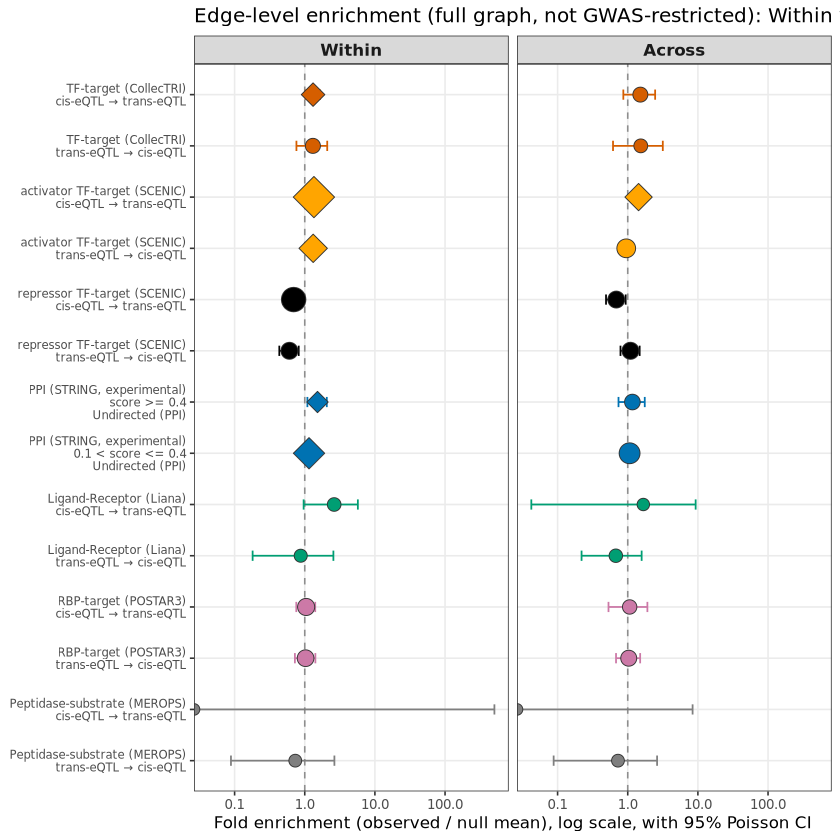

In [47]:

p_edge_full <- ggplot(edge_level_full[!is.na(fold_enrichment)],
                       aes(x = fold_enrichment, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = fold_ci_low, xmax = fold_ci_high, color = resource_key),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(aes(size = observed_hits, fill = resource_key, shape = sig_BH_05),
             color = "grey20", stroke = 0.4) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors, name = "Resource", labels = resource_legend_labels) +
  scale_color_manual(values = resource_colors, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(3, 9)) +
  scale_x_log10() +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  facet_grid(cols = vars(edge_type)) +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI",
    y = NULL,
    title = "Edge-level enrichment (full graph, not GWAS-restricted): Within vs Across"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 7),
    strip.text = element_text(size = 10, face = "bold"),
    panel.grid.minor = element_blank(),
    legend.text = element_text(size = 8),
      legend.position="hidden"
  ) +
  guides(fill = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1))

ggsave(paste0(global_plots_dir, "edge_level_full_within_across_facet.png"), p_edge_full,
       width = 10, height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(global_plots_dir, "edge_level_full_within_across_facet.pdf"), p_edge_full,
       width = 10, height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

p_edge_full

### SAVE

In [45]:
## =============================================================================
## Save edge-level (full graph) results + all plotting metadata to Global_plots
## =============================================================================
edge_level_plot_metadata <- list(
  resource_colors          = resource_colors,          # loaded from cis-eQTL bundle, reused here for cross-level consistency
  resource_legend_labels   = resource_legend_labels,
  row_order_top_to_bottom  = row_order_top_to_bottom,   # recycled verbatim label spec, see notebook comment
  axis_limits_bottom_to_top = axis_limits_bottom_to_top,

  facet_variable     = "edge_type",
  subset_applied     = "graph_type == 'full' (GWAS_colocalized excluded)",
  x_variable         = "fold_enrichment (observed_hits / null_mean)",
  ci_method          = "Exact Poisson CI (qchisq-based) on observed_hits, divided by null_mean; NA where null_mean == 0",
  odds_or_fold_note  = "This is fold_enrichment from the curveball permutation null, NOT a Fisher odds ratio - not directly comparable in magnitude to cis-eQTL/pattern-level odds ratios, only in direction/significance.",

  source_cis_eqtl_bundle = cis_eqtl_bundle_path,
  generated_on = Sys.time(),
  r_session    = capture.output(sessionInfo())
)

edge_level_full_bundle <- list(
  edge_level_full = edge_level_full,       # the plotted data table itself, all derived columns included
  plot_metadata   = edge_level_plot_metadata
)

saveRDS(edge_level_full_bundle, file = paste0(global_plots_dir, "edge_level_full_results_bundle.rds"))

## Human-readable companions
fwrite(edge_level_full, paste0(global_plots_dir, "edge_level_full_results.tsv"), sep = "\t")

metadata_flat <- data.table(
  field = c("facet_variable", "subset_applied", "x_variable", "ci_method", "odds_or_fold_note",
            "source_cis_eqtl_bundle", "generated_on"),
  value = c(edge_level_plot_metadata$facet_variable, edge_level_plot_metadata$subset_applied,
            edge_level_plot_metadata$x_variable, edge_level_plot_metadata$ci_method,
            edge_level_plot_metadata$odds_or_fold_note, edge_level_plot_metadata$source_cis_eqtl_bundle,
            as.character(edge_level_plot_metadata$generated_on))
)
fwrite(metadata_flat, paste0(global_plots_dir, "edge_level_plot_metadata_summary.tsv"), sep = "\t")

cat("Saved bundle to:", paste0(global_plots_dir, "edge_level_full_results_bundle.rds"), "\n")
cat("Saved companions: edge_level_full_results.tsv, edge_level_plot_metadata_summary.tsv\n")

Saved bundle to: /nfs/team151/mt19/overhaul_classification_factors_with_programs/Global_plots/edge_level_full_results_bundle.rds 
Saved companions: edge_level_full_results.tsv, edge_level_plot_metadata_summary.tsv
